In [1]:
import os
import glob
import cv2
import seaborn as sns
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn import metrics
from tensorflow.keras.regularizers import l2
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dropout, Flatten, Dense
from keras.models import Sequential
from keras.layers import BatchNormalization
from tensorflow.keras.metrics import Precision, Recall, AUC, F1Score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomBrightness, RandomContrast, Rescaling
import warnings
warnings.filterwarnings("ignore")

In [4]:

#data augmentacion, e os pedos na loss

model = Sequential()

# Pamameters Initialization
input_shape = (224, 224, 3)
activation = 'relu'
padding = 'same'
droprate = 0.1
epsilon=0.001

model = Sequential()

model.add(RandomFlip("horizontal_and_vertical"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomTranslation(0.2, 0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))
model.add(BatchNormalization(input_shape=input_shape))
model.add(Conv2D(filters=16, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))

model.add(Conv2D(filters=32, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))

model.add(Conv2D(filters=64, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))
model.add(Dropout(0.1))

model.add(Conv2D(filters=128, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))
model.add(Dropout(0.1))

model.add(Conv2D(filters=256, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))
model.add(Dropout(0.2))

model.add(Conv2D(filters=512, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))
model.add(Dropout(0.2))

model.add(Conv2D(filters=1024, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization(epsilon=epsilon))
model.add(Dropout(0.2))

model.add(Conv2D(filters=2048, kernel_size=3, activation=activation, padding=padding, kernel_regularizer=l2(0.001)))
model.add(BatchNormalization(epsilon=epsilon))
model.add(Dropout(0.2))

model.add(GlobalAveragePooling2D())
model.add(Dense(1, activation='sigmoid'))

In [3]:
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [4]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 224, 224, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3, 3, 512)      │         2,04

 Total params: 25,187,181 (96.08 MB)

 Trainable params: 25,179,015 (96.05 MB)

 Non-trainable params: 8,166 (31.90 KB)

In [5]:
image_gen = ImageDataGenerator()

In [6]:
train_generator = image_gen.flow_from_directory(
    'dataset/train/',
    target_size=(224, 224),
    batch_size=10,
    class_mode='binary'
)

Found 90000 images belonging to 2 classes.


In [ ]:
valid_generator = image_gen.flow_from_directory(
    'dataset/valid/',
    target_size=(224, 224),
    batch_size=10,
    class_mode='binary'
)

Found 15000 images belonging to 2 classes.


In [ ]:
class_weights = {0: 0.25, 1: 0.75}

history = model.fit(
    train_generator,
    steps_per_epoch = (90000//100),
    validation_data = valid_generator,
    validation_steps = (15000//100),
    epochs = 1
)

900/900 ━━━━━━━━━━━━━━━━━━━━ 476s 526ms/step - accuracy: 0.6646 - loss: 2.6267 - val_accuracy: 0.7580 - val_loss: 1.5967


In [50]:
test_generator = image_gen.flow_from_directory(
    'dataset/test/',
    target_size=(224, 224),
    batch_size=10,
    color_mode='grayscale',
    class_mode='binary'
)

Found 15000 images belonging to 2 classes.


In [51]:
y_pred = model.predict(test_generator)
y_test = test_generator.classes

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 68ms/step


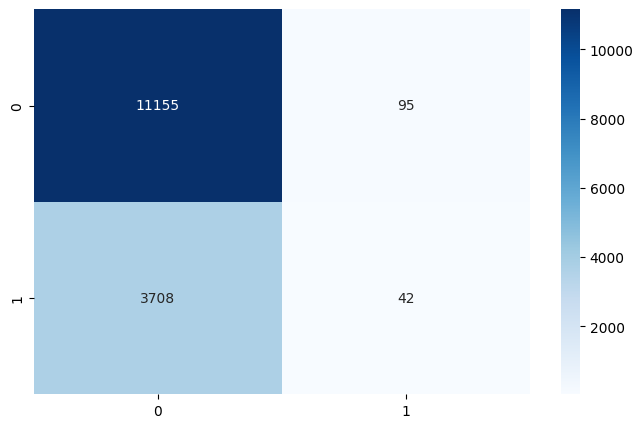

In [52]:
plt.figure(figsize = (8,5))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred.round()), annot = True,fmt="d",cmap = "Blues")
plt.show()

In [53]:
print("ROC-AUC Score:", metrics.roc_auc_score(y_test, y_pred))
print("AP Score:", metrics.average_precision_score(y_test, y_pred))

ROC-AUC Score: 0.5067202844444444
AP Score: 0.25646588374265444


In [57]:
print(metrics.classification_report(y_test, y_pred > 0.5))

              precision    recall  f1-score   support

           0       0.75      0.99      0.85     11250
           1       0.31      0.01      0.02      3750

    accuracy                           0.75     15000
   macro avg       0.53      0.50      0.44     15000
weighted avg       0.64      0.75      0.65     15000



In [60]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

def prever_imagem_unica_keras(caminho_imagem, modelo, tamanho_alvo=(224, 224)):
    img = image.load_img(caminho_imagem, target_size=tamanho_alvo, color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=(0, 3))
    previsao = modelo.predict(img_array)
    return previsao

caminho_imagem = './dataset/valid/real/2575_1946-05-19_1980_wiki.jpg'
previsao = prever_imagem_unica_keras(caminho_imagem, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [62]:
print(previsao)

[[0.162917]]
